In [1]:
import pandas as pd
from modules.sentiment.rag.embedder import Embedder
from modules.sentiment.rag.vector_store import QdrantVectorStore
from modules.sentiment.rag.retriever import Retriever
from modules.sentiment.rag.generator import Generator
from modules.sentiment.evaluation.rag_metrics import faithfulness


c:\Users\sarfras\anaconda3\envs\crypto\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


         id                                            content source  length
0  26410709  Legendary trader who predicted 1980s gold cras...   news     159
1  26410499  Tesla Posts $80 Million Bitcoin Profit Tesla P...   news      77
2  26411106  AI Picks Chainlink (LINK) as Top Crypto for Fo...   news     143
3  26410751  Canaan’s Turnaround Gains Steam as Benchmark D...   news     143
4  26410207  Bitcoin Price Prediction: Standard Chartered P...   news     195


<Axes: >

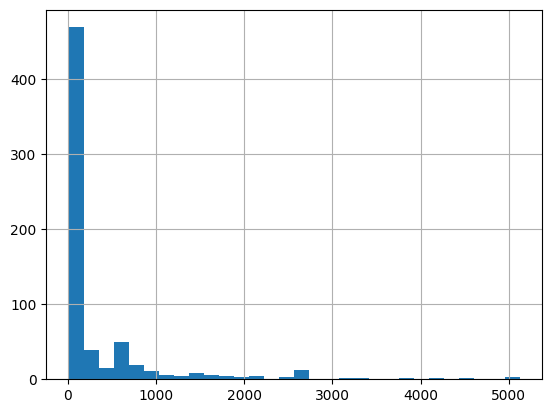

In [2]:
embedder = Embedder()
docs = embedder.fetch_docs()
df_docs = pd.DataFrame(docs)
df_docs['length'] = df_docs['content'].str.len()

print(df_docs.head())
df_docs['length'].hist(bins=30)

In [3]:
vector_store = QdrantVectorStore()
retriever = Retriever(embedder, vector_store)
query = "what is the current situation of ETH"
results = retriever.retrieve(query)

pd.DataFrame([{"score": r['score'], "content": r['content']} for r in results])

,score,content
0,1.200000,"Eth literally burned fees to reduce supply, th..."
1,1.161905,"in contrast Eth and others use proof of stake,..."
2,0.983871,"ETH as a universal bond\n\nIn this model, **ET..."
3,0.953125,ETH Snaps Back as Whales Load $480M and Cowen ...
4,0.938462,Ethereum erases its 2025 gains: Is ETH price h...


In [4]:
generator = Generator()
response = generator.generate(query, results) 

print("Query:", query)
print("\nResponse:", response)

Device set to use cpu
Both `max_new_tokens` (=300) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: what is the current situation of ETH

Response: The price of ETH has fallen 21% and is now at $2.2K.


In [5]:
contexts = [r['content'] for r in results]
faith = faithfulness(response, contexts)
print(f"Faithfulness: {faith:.4f}")

Faithfulness: 0.6667
